# Week 9: TimeSeries Forcasting using Linear Regression

MTU Spring 2025

Instructor: Amna Mazen

## Linear Regression with Time Series

- First, we'll use the linear regression algorithm to construct forecasting models. Linear regression is widely used in practice and adapts naturally to even complex forecasting tasks.

- The linear regression algorithm learns how to make a weighted sum from its input features. For two features, we would have:

`target = weight_1 * feature_1 + weight_2 * feature_2 + bias`

- During training, the regression algorithm learns values for the parameters `weight_1`, `weight_2`, and `bias` that best fit the target.

- This algorithm is often called ordinary least squares since it chooses values that minimize the squared error between the target and the predictions.

-  The weights are also called regression coefficients and the bias is also called the intercept because it tells you where the graph of this function crosses the y-axis.



#### Time-step features

There are two kinds of features unique to time series: `time-step features` and `lag features`.

Time-step features are features we can derive directly from the time index. The most basic time-step feature is the time dummy, which counts off time steps in the series from beginning to end.

### Hardcover Book Sale Forcasting

This series records the number of hardcover book sales at a retail store over **30** days. Notice that we have a single column of observations Hardcover with a time index **Date**.

In [2]:
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/refs/heads/main/Dataset/Lecture_Dataset/book_sales.csv",
    index_col='Date',
    parse_dates=['Date'],
).drop('Paperback', axis=1)

df.head()

,Hardcover
Date,
2000-04-01,139
2000-04-02,128
2000-04-03,172
2000-04-04,139
2000-04-05,191


####Time-step feature
Provided the time series doesn't have any missing dates, **we can create a time dummy by counting out the length of the series.**

In [3]:
import numpy as np

df['Time'] = np.arange(len(df.index))

df.head()

,Hardcover,Time
Date,,
2000-04-01,139,0
2000-04-02,128,1
2000-04-03,172,2
2000-04-04,139,3
2000-04-05,191,4


Linear regression with the time dummy produces the model:

`target = weight * time + bias`

The time dummy then lets us fit curves to time series in a time plot, where Time forms the x-axis.

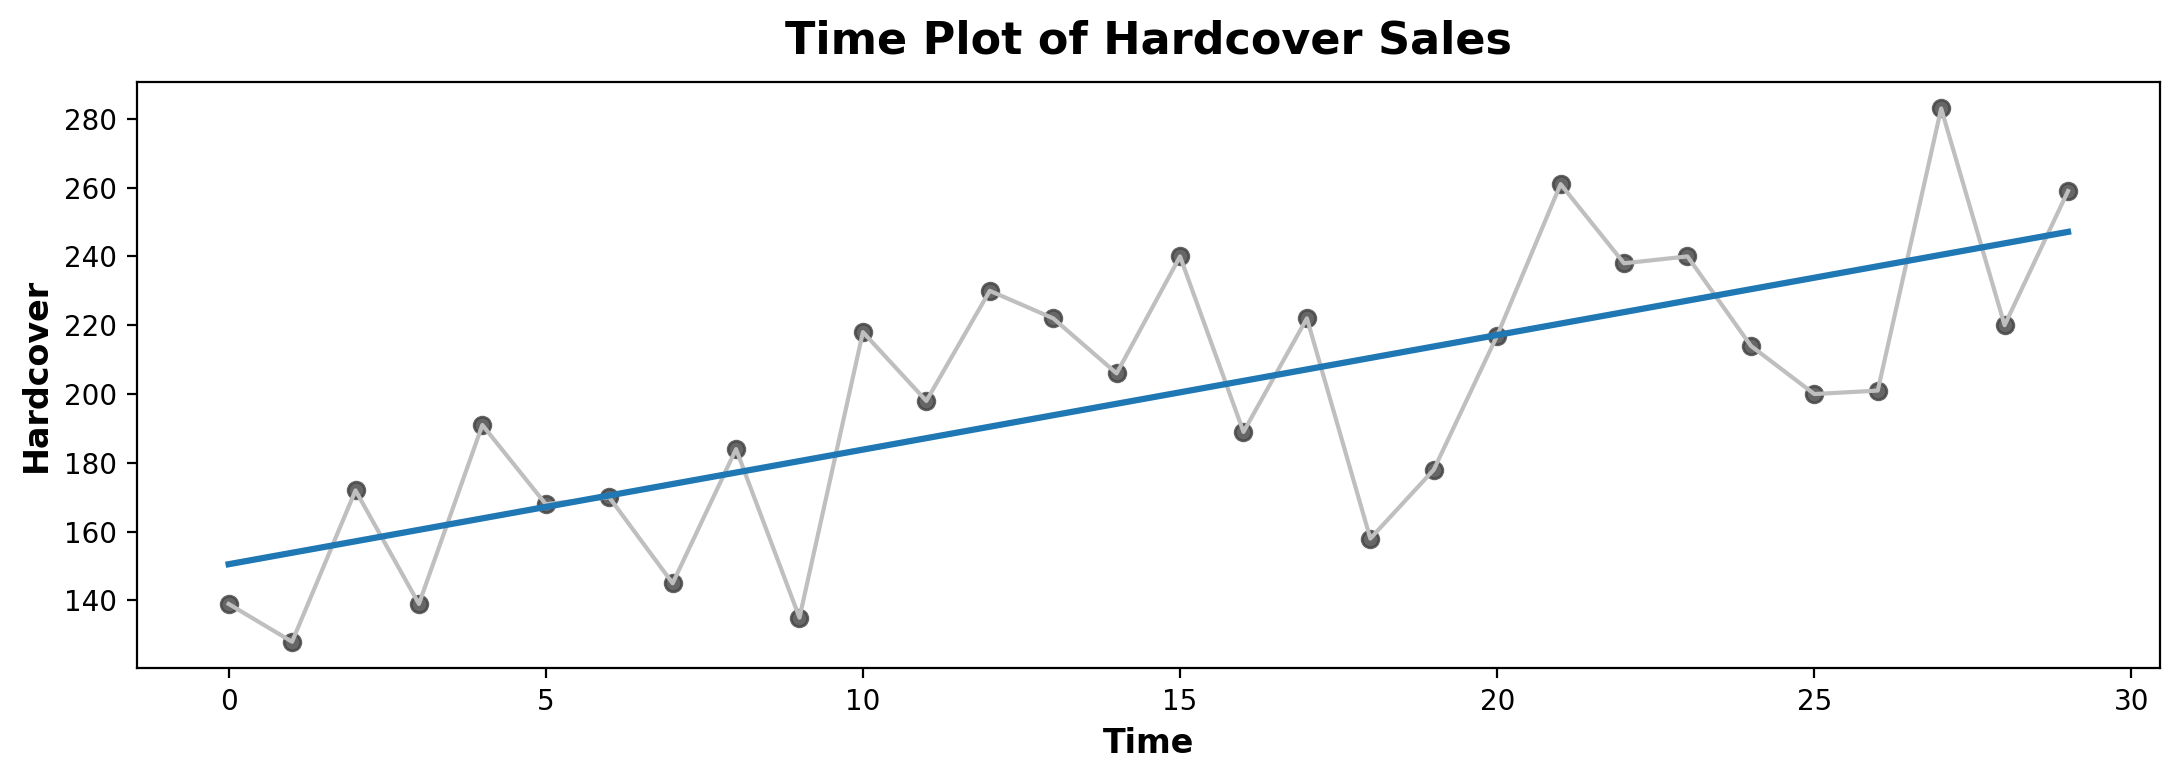

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
#plt.style.use("seaborn-white")
plt.rc(
    "figure",
    autolayout=True,
    figsize=(11, 4),
    titlesize=18,
    titleweight='bold',
)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
%config InlineBackend.figure_format = 'retina'

fig, ax = plt.subplots()
ax.plot('Time', 'Hardcover', data=df, color='0.75')
ax = sns.regplot(x='Time', y='Hardcover', data=df, ci=None, scatter_kws=dict(color='0.25'))
ax.set_title('Time Plot of Hardcover Sales');

Time-step features let you model **time dependence**. A series is time dependent if its values can be predicted from the time they occured. In the Hardcover Sales series, we can predict that sales later in the month are generally higher than sales earlier in the month.

#### Lag features
To make a lag feature we shift the observations of the target series so that they appear to have occured later in time.

Here we've created a 1-step lag feature, though shifting by multiple steps is possible too.

In [5]:
df['Lag_1'] = df['Hardcover'].shift(1)
df = df.reindex(columns=['Hardcover', 'Lag_1'])

df.head()

,Hardcover,Lag_1
Date,,
2000-04-01,139,NaN
2000-04-02,128,139.0
2000-04-03,172,128.0
2000-04-04,139,172.0
2000-04-05,191,139.0


Linear regression with a lag feature produces the model:

`target = weight * lag + bias`

So lag features let us fit curves to lag plots where each observation in a series is plotted against the previous observation.

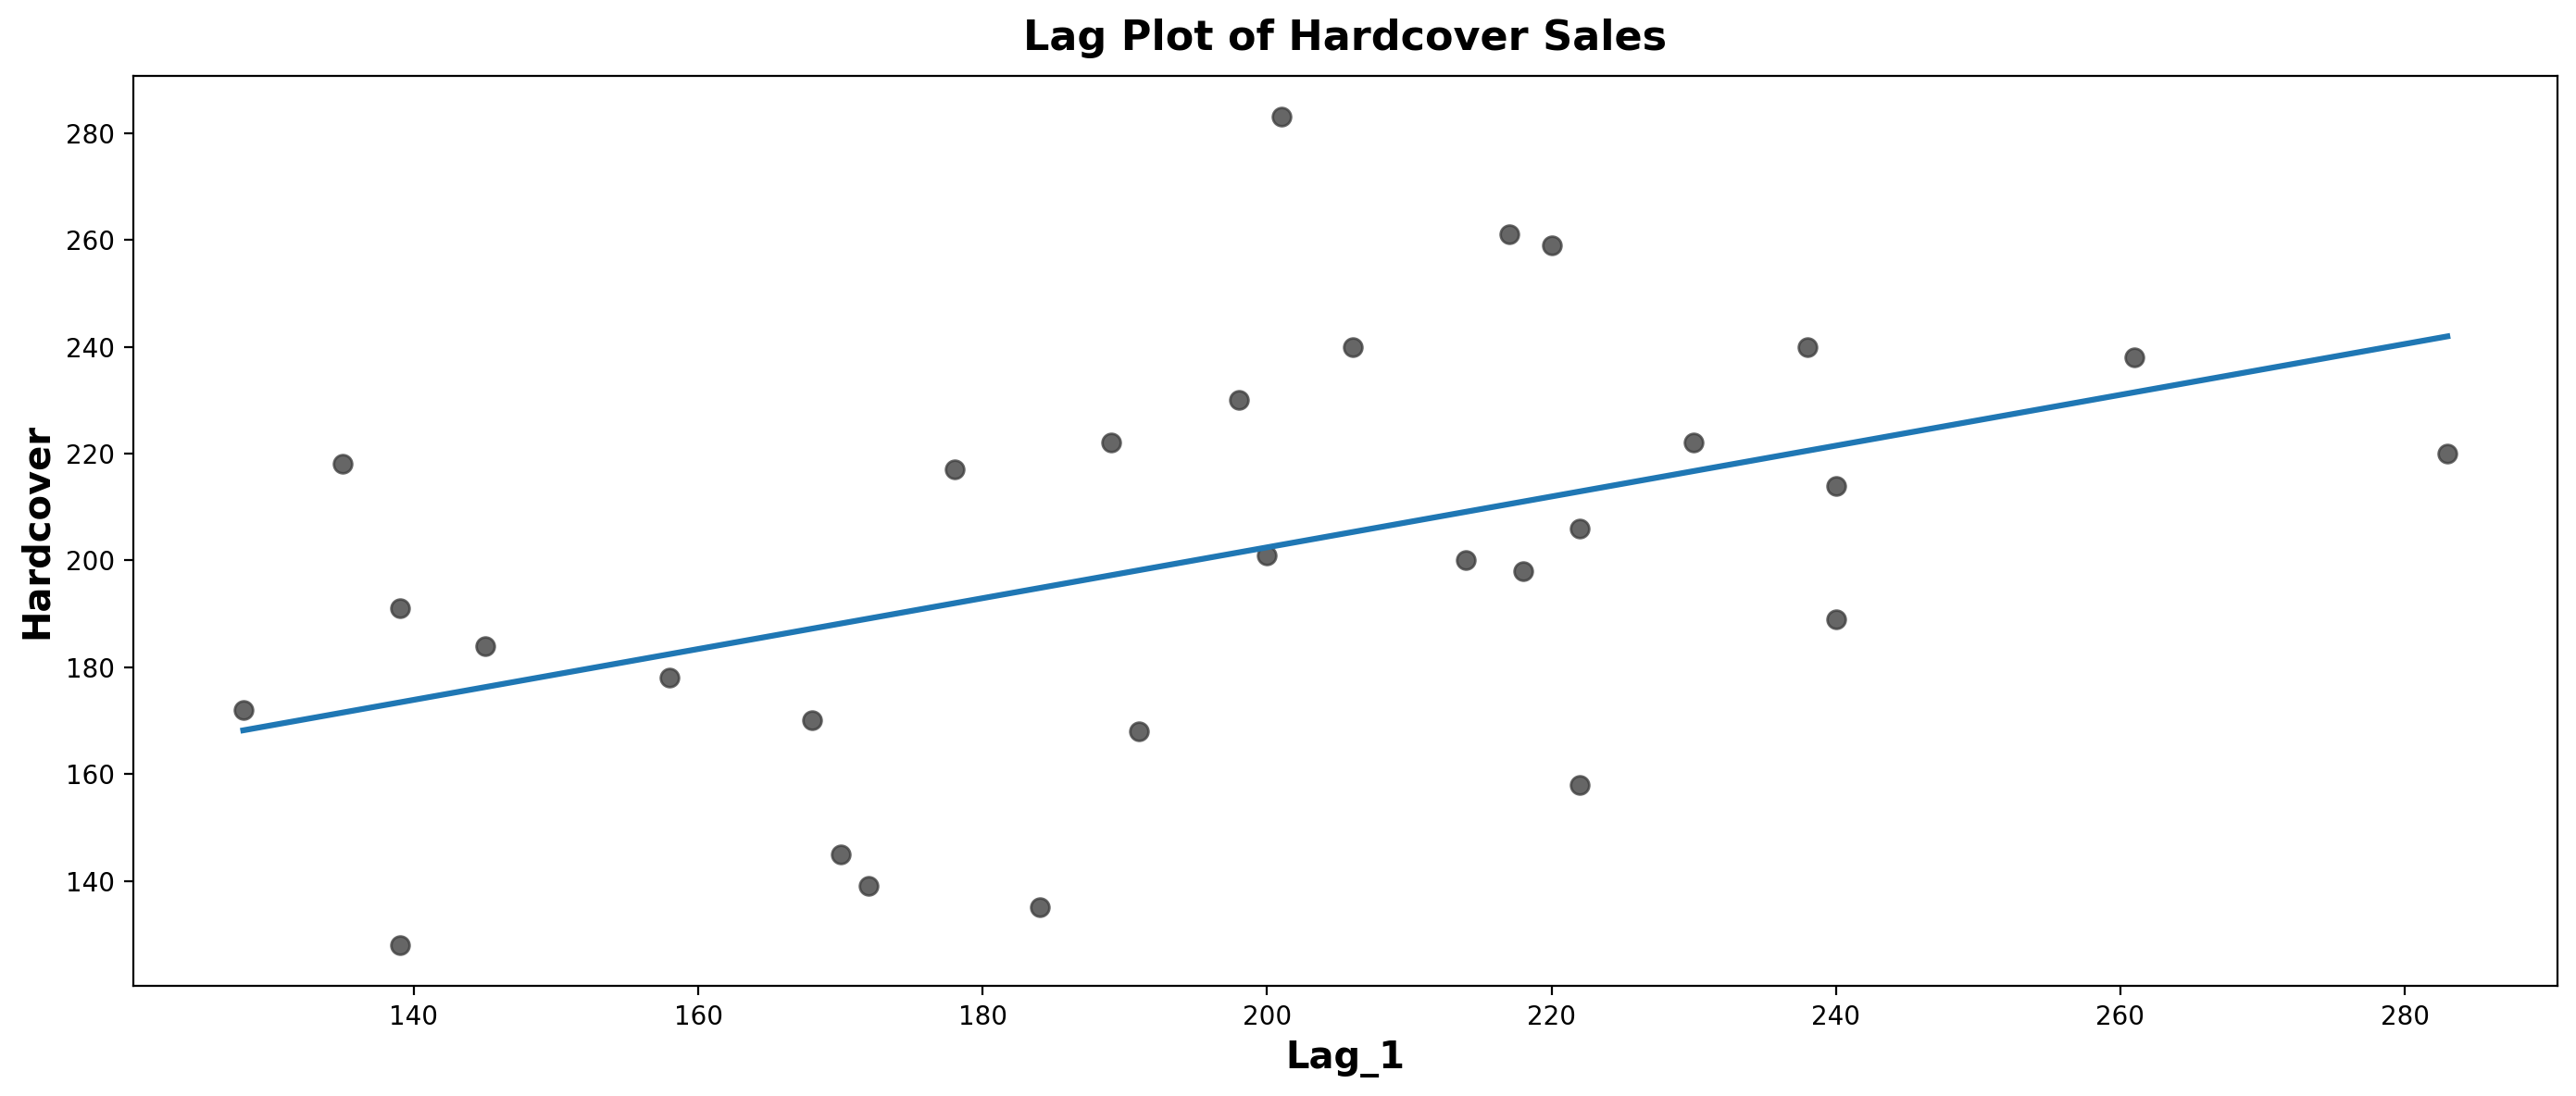

In [8]:
plt.rc(
    "figure",
    autolayout=True,
    figsize=(14, 6),  # Increased figure size
    titlesize=18,
    titleweight='bold',
)

plt.rc(
    "axes",
    labelweight="bold",
    labelsize="x-large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)

%config InlineBackend.figure_format = 'retina'

fig, ax = plt.subplots()
ax = sns.regplot(
    x='Lag_1',
    y='Hardcover',
    data=df,
    ci=None,
    scatter_kws=dict(color='0.25', s=50)  # s controls dot size
)
ax.set_aspect('auto')  # Allow axis to fill space more naturally
ax.set_title('Lag Plot of Hardcover Sales')

plt.tight_layout()  # Adjust layout to use space more efficiently


**You can see from the lag plot that sales on one day (`Hardcover`) are correlated with sales from the previous day (`Lag_1`).** When you see a relationship like this, you know a lag feature will be useful.

More generally, lag features let you model **serial dependence**. A time series has serial dependence when an observation can be predicted from previous observations. In Hardcover Sales, we can predict that high sales on one day usually mean high sales the next day.

### Example - Tunnel Traffic

Tunnel Traffic is a time series describing the number of vehicles traveling through the `Baregg Tunnel` in `Switzerland` each day from `November 2003` to `November 2005`. In this example, we'll get some practice applying linear regression to time-step features and lag features.

In [9]:
#from pathlib import Path
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

simplefilter("ignore")  # ignore warnings to clean up output cells

# Set Matplotlib defaults
#plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)
%config InlineBackend.figure_format = 'retina'


# Load Tunnel Traffic dataset
tunnel = pd.read_csv("https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/refs/heads/main/Dataset/Lecture_Dataset/tunnel.csv", parse_dates=["Day"])

# Create a time series in Pandas by setting the index to a date
# column. We parsed "Day" as a date type by using `parse_dates` when
# loading the data.
tunnel = tunnel.set_index("Day")

# By default, Pandas creates a `DatetimeIndex` with dtype `Timestamp`
# (equivalent to `np.datetime64`, representing a time series as a
# sequence of measurements taken at single moments. A `PeriodIndex`,
# on the other hand, represents a time series as a sequence of
# quantities accumulated over periods of time. Periods are often
# easier to work with, so that's what we'll use in this course.
tunnel = tunnel.to_period()

tunnel.head()

,NumVehicles
Day,
2003-11-01,103536
2003-11-02,92051
2003-11-03,100795
2003-11-04,102352
2003-11-05,106569


####Time-step feature
Provided the time series doesn't have any missing dates, **we can create a time dummy by counting out the length of the series.**

In [10]:
df = tunnel.copy()

df['Time'] = np.arange(len(tunnel.index))

df.head()

,NumVehicles,Time
Day,,
2003-11-01,103536,0
2003-11-02,92051,1
2003-11-03,100795,2
2003-11-04,102352,3
2003-11-05,106569,4


The procedure for fitting a linear regression model follows the standard steps for scikit-learn

In [11]:
from sklearn.linear_model import LinearRegression

# Training data
X = df.loc[:, ['Time']]  # features
y = df.loc[:, 'NumVehicles']  # target

# Train the model
model = LinearRegression()
model.fit(X, y)

# Store the fitted values as a time series with the same time index as
# the training data
y_pred = pd.Series(model.predict(X), index=X.index)

# Get the coefficient and intercept
coefficient = model.coef_[0]
intercept = model.intercept_

# Print results
print(f"Coefficient: {coefficient}")
print(f"Intercept: {intercept}")

Coefficient: 22.49744953347821
Intercept: 98176.20634409295


The model actually created is (approximately):

`Vehicles = 22.5 * Time + 98176.`

Plotting the fitted values over time shows us how fitting linear regression to the time dummy creates the trend line defined by this equation.

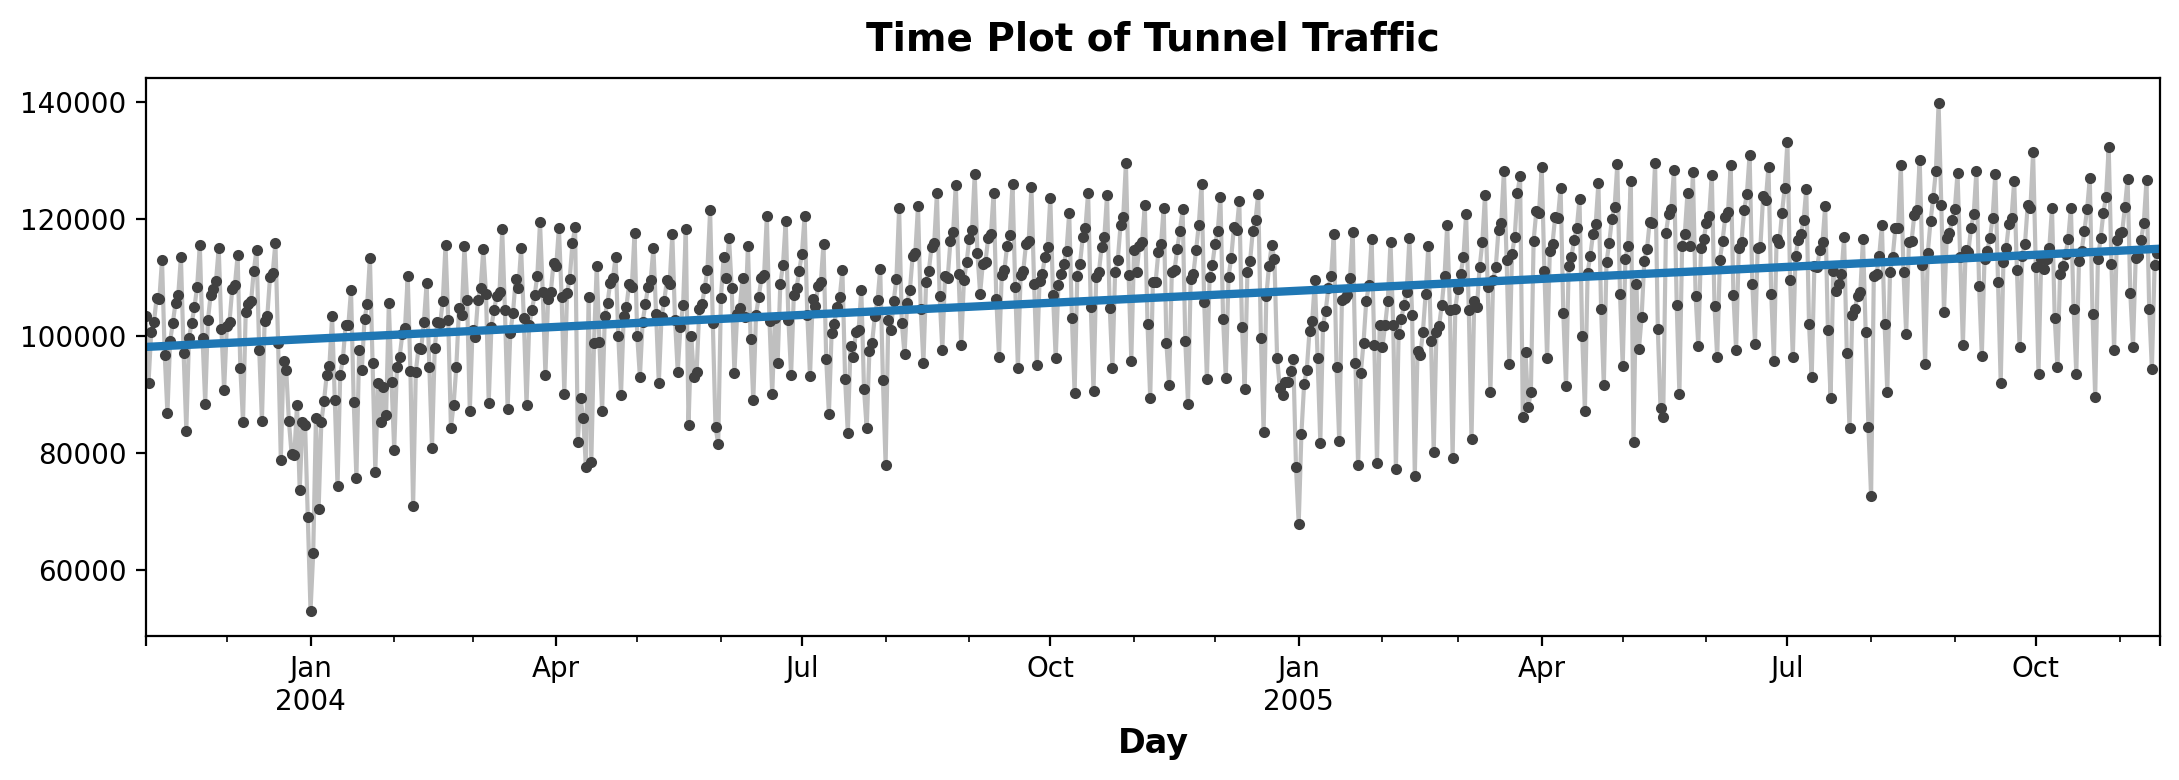

In [12]:
ax = y.plot(**plot_params)
ax = y_pred.plot(ax=ax, linewidth=3)
ax.set_title('Time Plot of Tunnel Traffic');

#### Lag feature
Pandas provides us a simple method to lag a series, the `shift` method.



In [13]:
df['Lag_1'] = df['NumVehicles'].shift(1)
df.head()

,NumVehicles,Time,Lag_1
Day,,,
2003-11-01,103536,0,NaN
2003-11-02,92051,1,103536.0
2003-11-03,100795,2,92051.0
2003-11-04,102352,3,100795.0
2003-11-05,106569,4,102352.0


When creating lag features, we need to decide what to do with the **missing values** produced. Filling them in is one option, maybe with `0.0` or "backfilling" with the first known value. Instead, we'll just `drop` the missing values, making sure to also drop values in the target from corresponding dates.


In [14]:
from sklearn.linear_model import LinearRegression

X = df.loc[:, ['Lag_1']]
X.dropna(inplace=True)  # drop missing values in the feature set
y = df.loc[:, 'NumVehicles']  # create the target
y, X = y.align(X, join='inner')  # drop corresponding values in target

model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

# Get the coefficient and intercept
coefficient = model.coef_[0]
intercept = model.intercept_

# Print results
print(f"Coefficient: {coefficient}")
print(f"Intercept: {intercept}")

Coefficient: 0.5329660641208309
Intercept: 49780.62486906959


The lag plot shows us how well we were able to fit the relationship between the number of vehicles one day and the number the previous day.

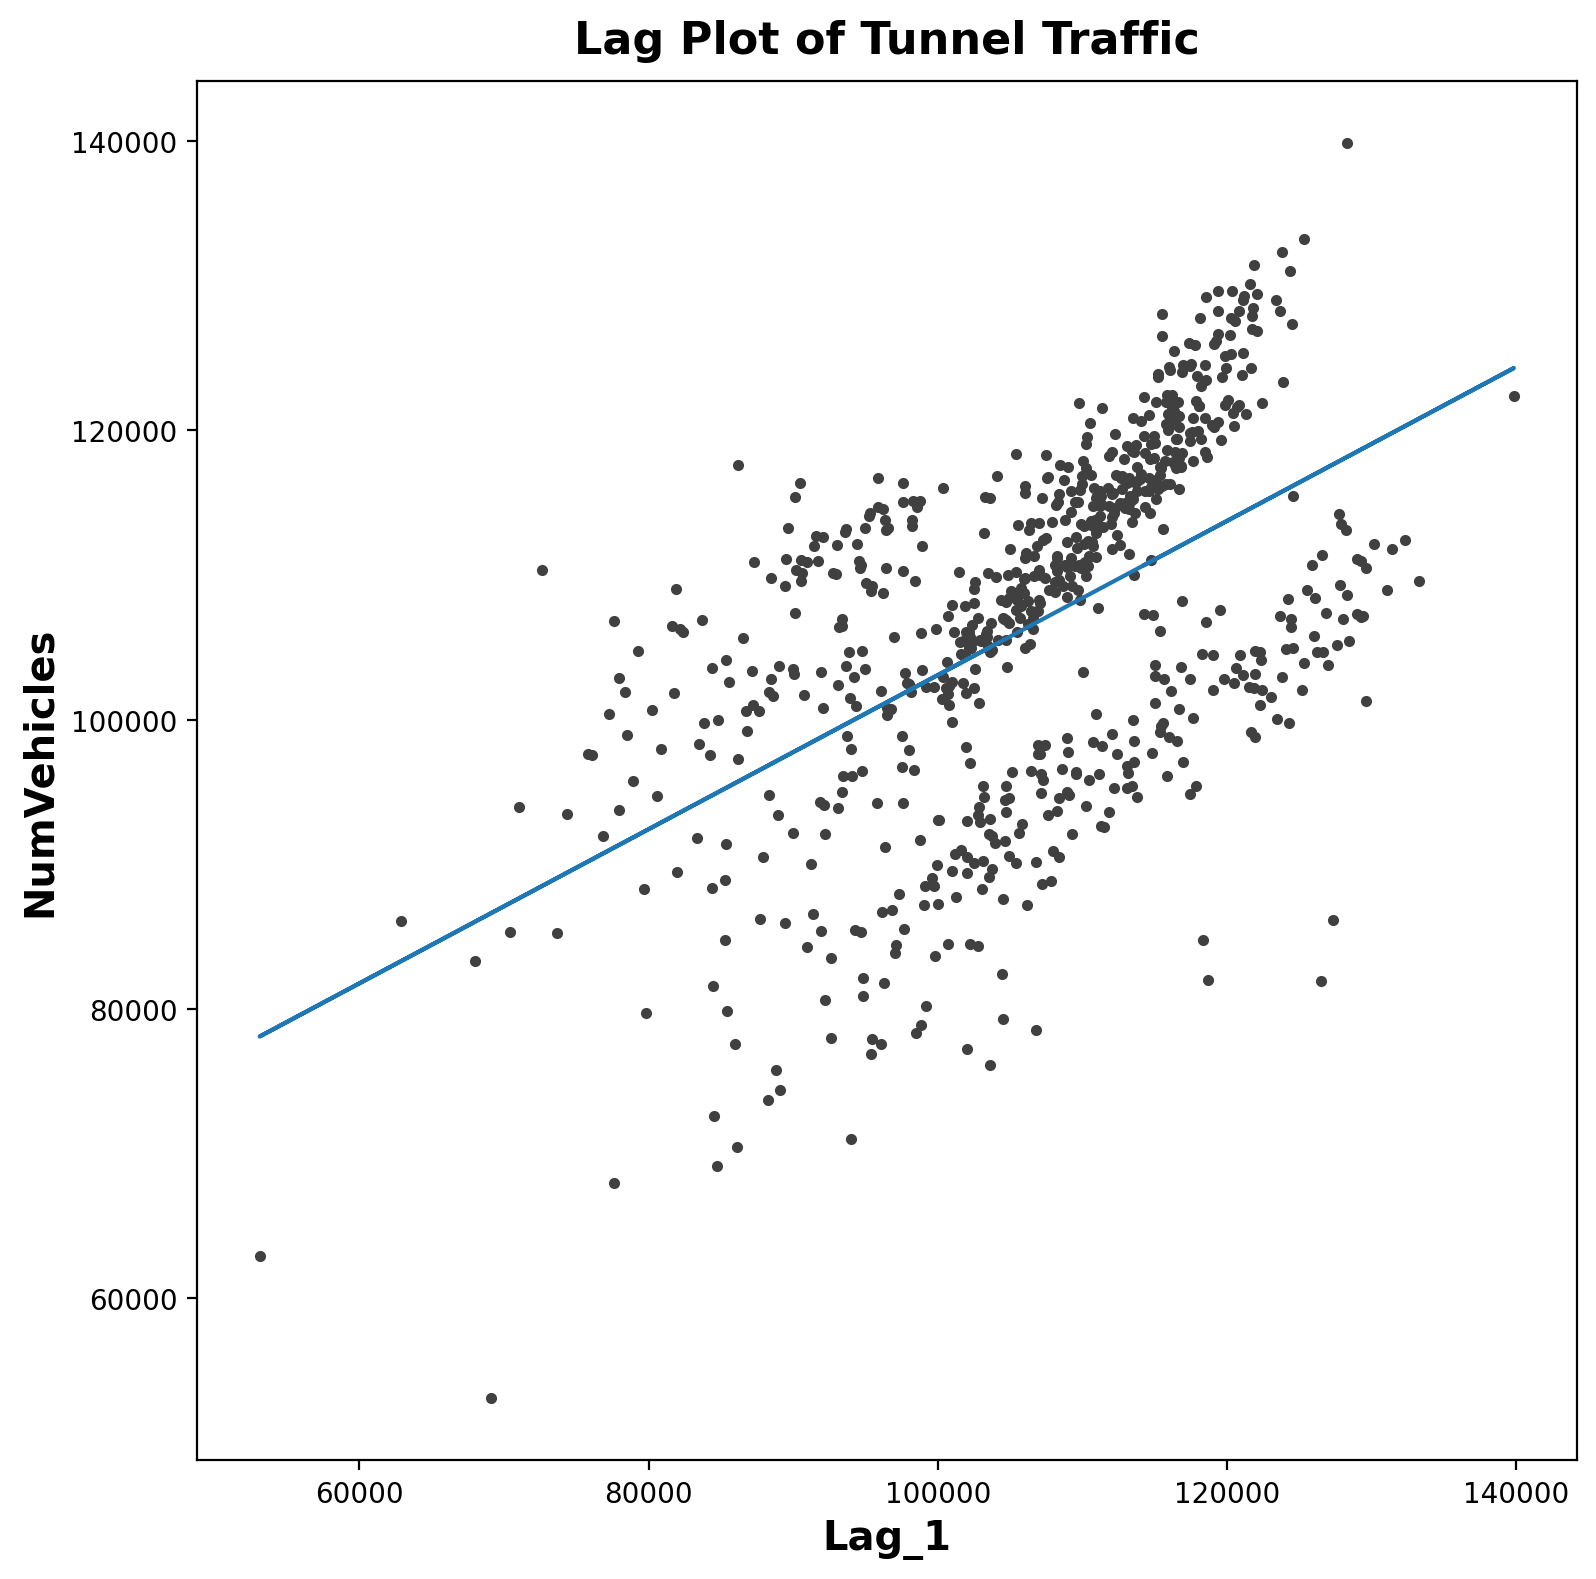

In [17]:
plt.rc(
    "figure",
    autolayout=True,
    figsize=(16, 8),  # Increased figure size
    titlesize=18,
    titleweight='bold',
)

plt.rc(
    "axes",
    labelweight="bold",
    labelsize="x-large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)

%config InlineBackend.figure_format = 'retina'

fig, ax = plt.subplots()
ax.plot(X['Lag_1'], y, '.', color='0.25')
ax.plot(X['Lag_1'], y_pred)
ax.set_aspect('equal')
ax.set_ylabel('NumVehicles')
ax.set_xlabel('Lag_1')
ax.set_title('Lag Plot of Tunnel Traffic');

What does this prediction from a lag feature mean about how well we can predict the series across time? The following time plot shows us how our forecasts now respond to the behavior of the series in the recent past.

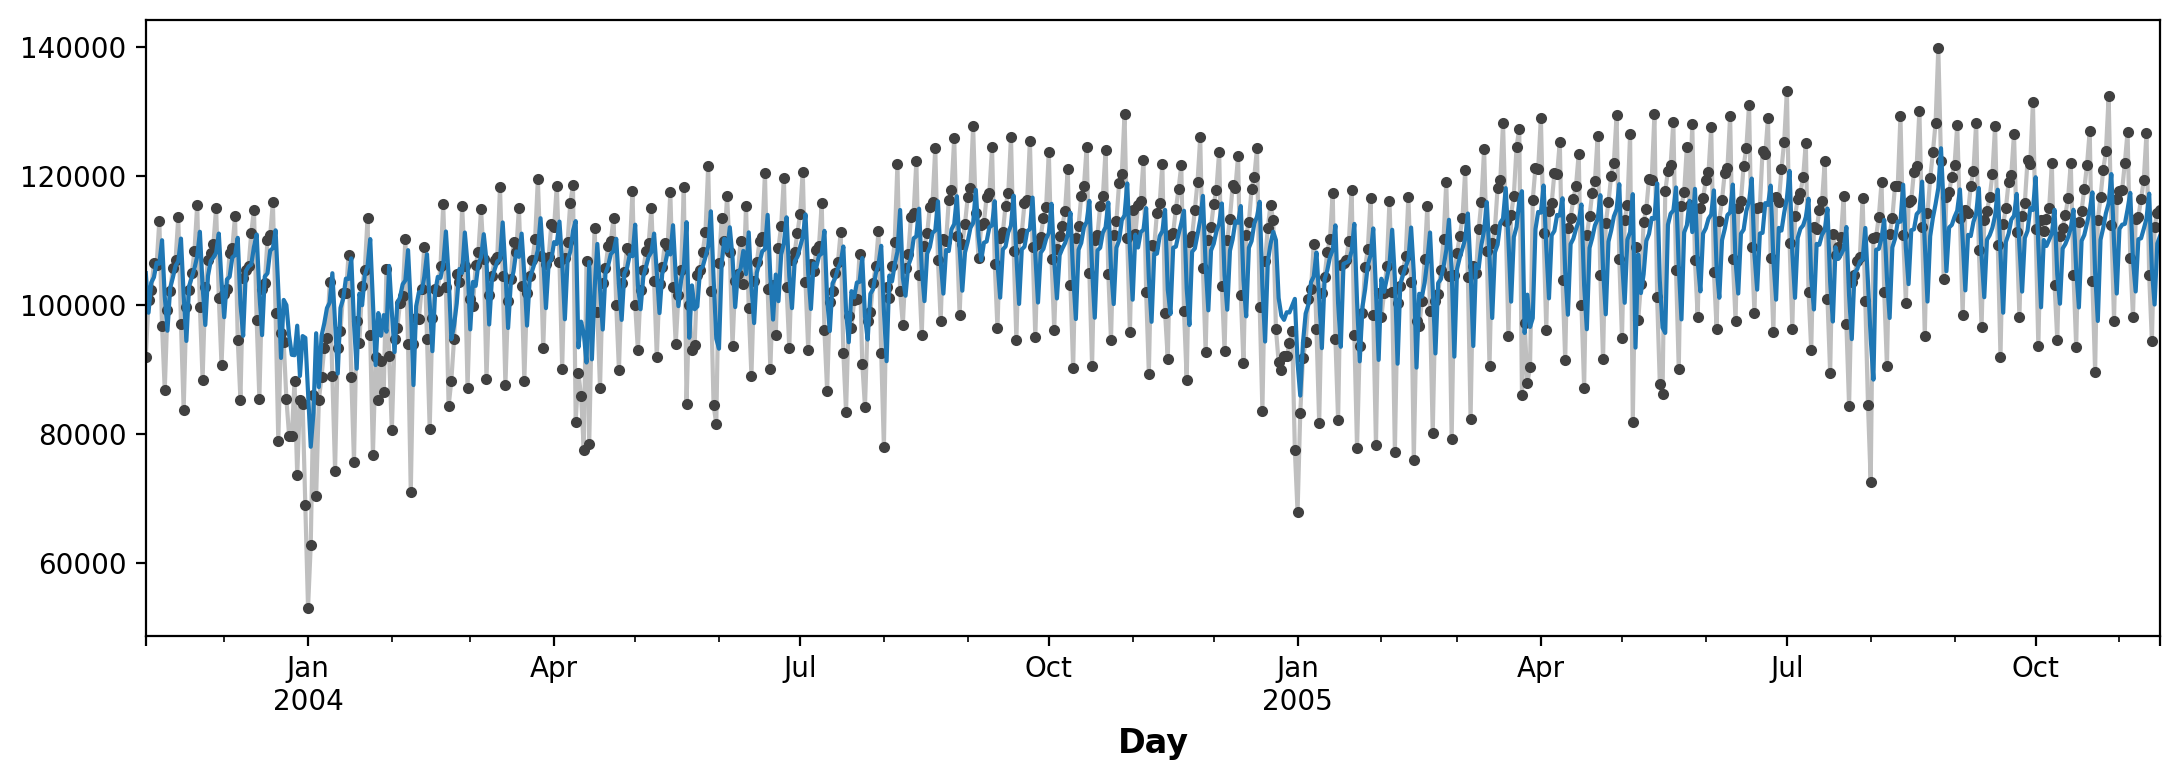

In [ ]:
ax = y.plot(**plot_params)
ax = y_pred.plot()

## Trend using Moving Average, kernel and exponential Smoothing

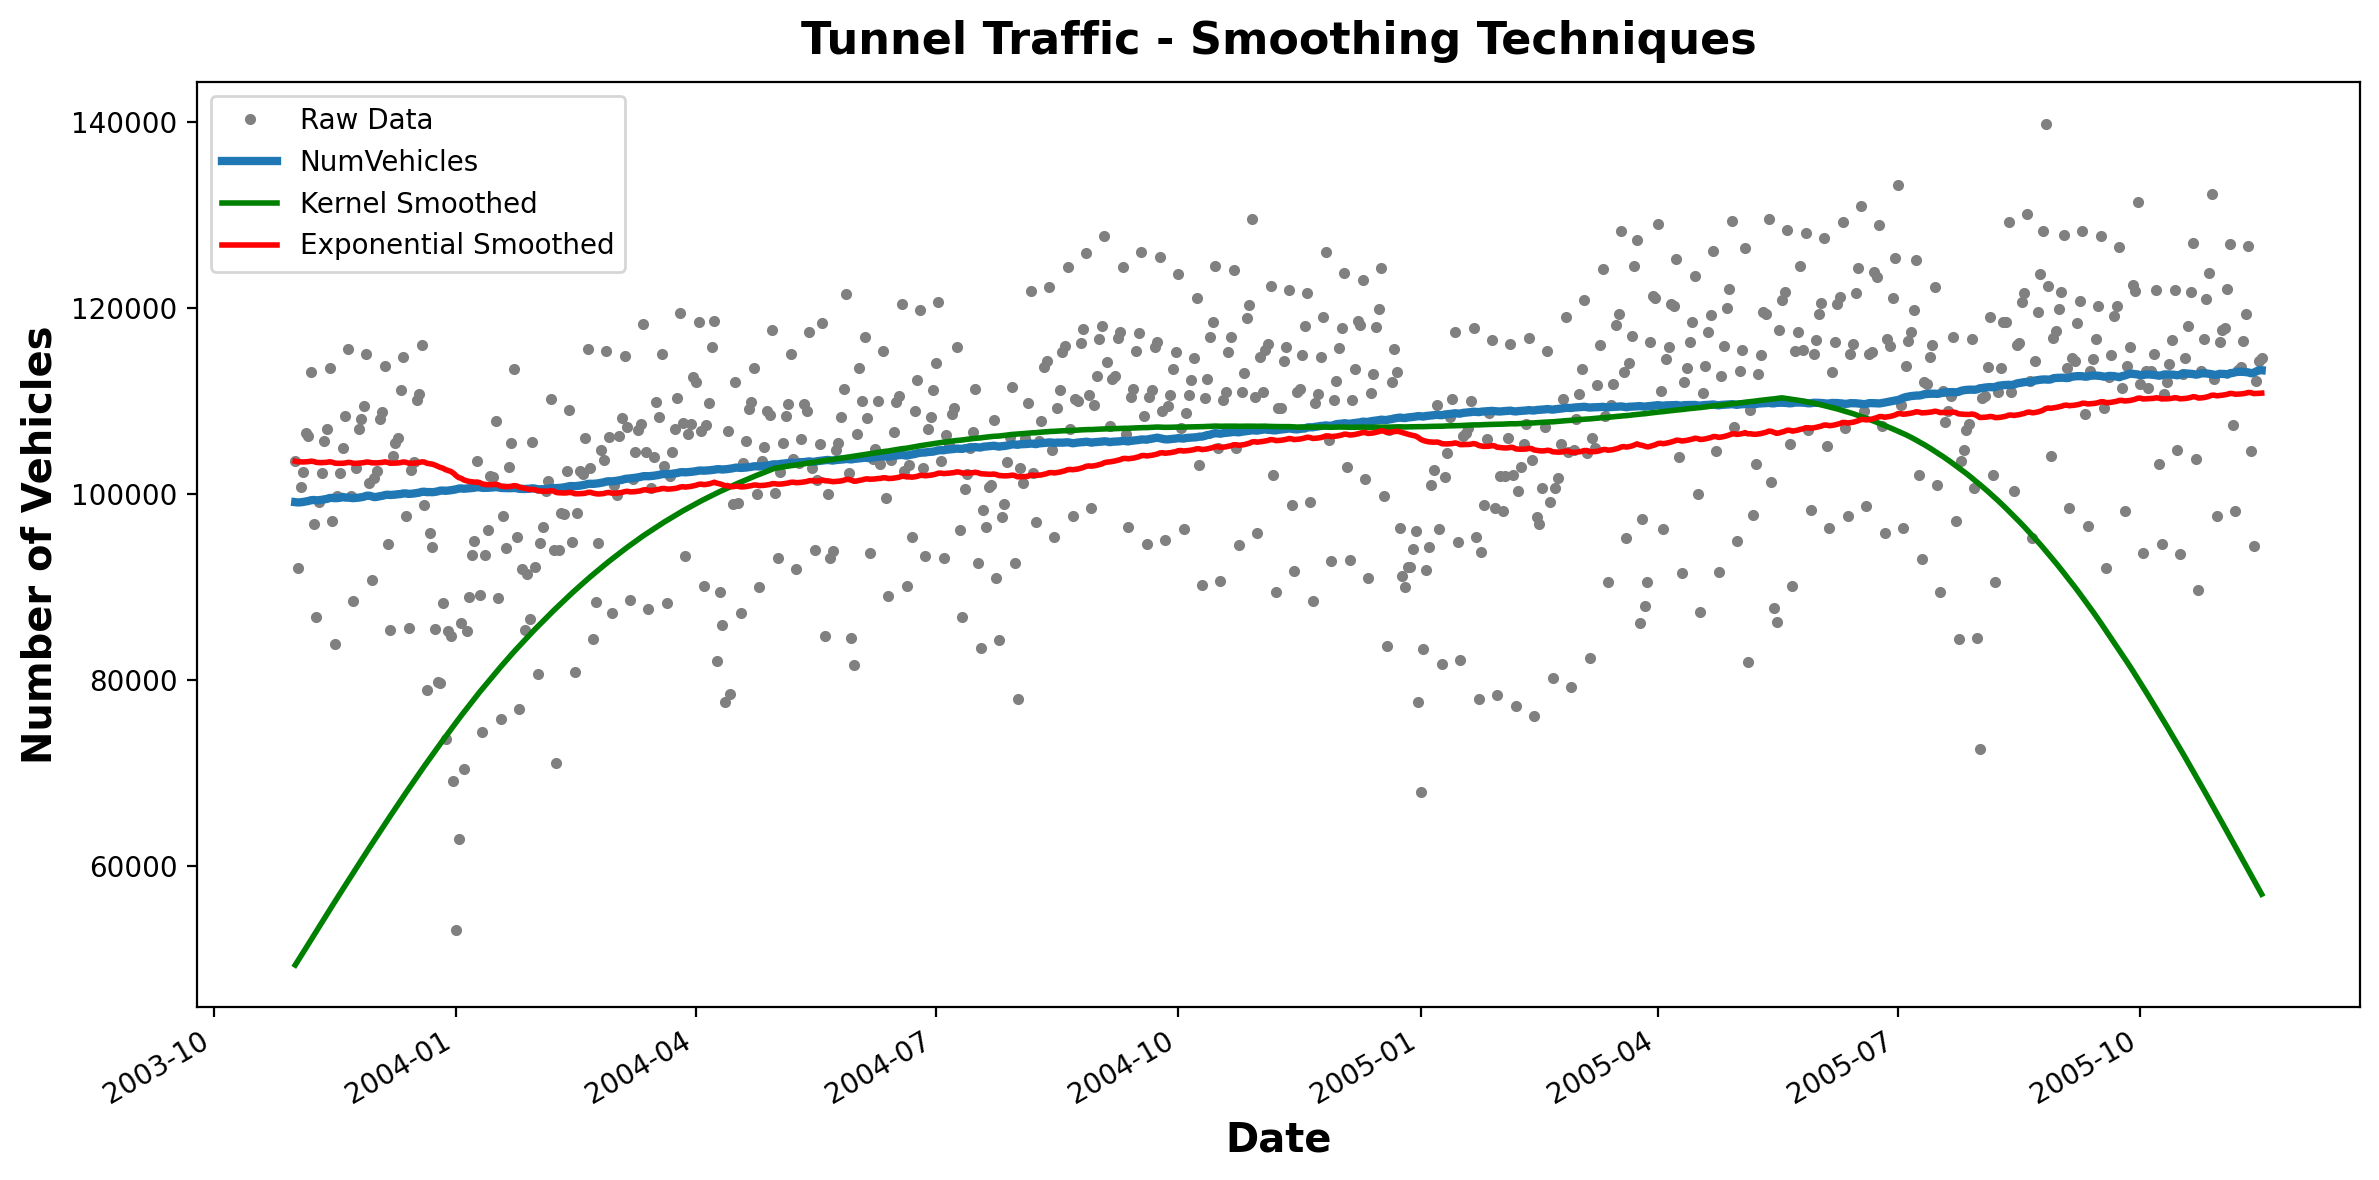

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example data: Replace this with your actual 'tunnel' DataFrame
# tunnel = pd.DataFrame({
#     'NumVehicles': np.random.randint(100, 1000, size=1000),  # Replace with your actual data
#     'Date': pd.date_range(start='2020-01-01', periods=1000, freq='D')
# })
# tunnel.set_index('Date', inplace=True)

# --- Moving Average ---
moving_average = tunnel.rolling(
    window=365,       # 365-day window
    center=True,      # places the average at the center of the window
    min_periods=183,  # choose about half the window size
).mean()             # compute the mean

# --- Kernel Smoothing ---
# Create a Gaussian kernel
kernel_size = 365
kernel = np.exp(-0.5 * (np.linspace(-2, 2, kernel_size) ** 2))  # Gaussian kernel
kernel /= kernel.sum()  # Normalize the kernel to sum to 1

# Apply the kernel smoothing
kernel_smoothed = np.convolve(tunnel['NumVehicles'], kernel, mode='same')

# --- Exponential Smoothing ---
# Single exponential smoothing
alpha = 0.1  # smoothing factor, between 0 and 1
exp_smoothed = tunnel['NumVehicles'].ewm(span=365, adjust=False).mean()

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the raw data
ax.plot(tunnel.index, tunnel['NumVehicles'], '.', color='0.5', label='Raw Data')

# Plot the smoothed data
moving_average.plot(ax=ax, linewidth=3, label="365-Day Moving Average")
ax.plot(tunnel.index, kernel_smoothed, color='green', linewidth=2, label='Kernel Smoothed')
ax.plot(tunnel.index, exp_smoothed, color='red', linewidth=2, label='Exponential Smoothed')

# Add title and labels
ax.set_title("Tunnel Traffic - Smoothing Techniques")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Vehicles")
ax.legend()

plt.show()



**Time Dummy in Pandas:**

In time series analysis or regression, a time dummy typically refers to a variable that represents time, often created by generating a sequence of numbers (e.g., 1, 2, 3, ...) or by encoding some features like date or time in a way that reflects temporal order.

For example, in Pandas, you might create a simple time variable using pd.Series like this:



In [ ]:

t = pd.Series(range(1, len(df) + 1))  # A simple time index


This works for some basic cases, but when dealing with time series data, this approach can become problematic for several reasons:

- **Missing Data:** If there are gaps in time, the linearity of the time variable may be disrupted.
- **Complexity:** As the time series model becomes more sophisticated (e.g., adding seasonal components, polynomial trends), manually constructing the right time dummies or time-related features can be error-prone.
- **Autocorrelation:** Time series data often has autocorrelation (dependencies between time points), which may not be addressed by a simple time variable. This can lead to incorrect model estimates.

Previously, we engineered our time dummy in Pandas directly. From now on, however, we'll use a function from the `statsmodels` library called `DeterministicProcess`. Using this function will help us avoid some tricky failure cases that can arise with time series and linear regression. The order argument refers to polynomial order: 1 for linear, 2 for quadratic, 3 for cubic, and so on.

The order argument in **DeterministicProcess** refers to the degree of the polynomial trend you want to include in your model:

- **Order 1:** This would create a linear trend (a straight line).
- **Order 2:** This would create a quadratic trend (a parabolic curve).
- **Order 3:** This would create a cubic trend (a cubic curve), and so on.
By increasing the order, you allow your model to account for more complex trends in the data.

In [ ]:
from statsmodels.tsa.deterministic import DeterministicProcess

dp = DeterministicProcess(
    index=tunnel.index,  # dates from the training data
    constant=True,       # dummy feature for the bias (y_intercept)
    order=1,             # the time dummy (trend)
    drop=True,           # drop terms if necessary to avoid collinearity
)
# `in_sample` creates features for the dates given in the `index` argument
X = dp.in_sample()

X.head()

,const,trend
Day,,
2003-11-01,1.0,1.0
2003-11-02,1.0,2.0
2003-11-03,1.0,3.0
2003-11-04,1.0,4.0
2003-11-05,1.0,5.0


(A deterministic process, by the way, is a technical term for a time series that is non-random or completely determined, like the `const` and `trend` series are. Features derived from the time index will generally be deterministic.)

We create our trend model basically as before, though note the addition of the fit_intercept=False argument.

In [ ]:
from sklearn.linear_model import LinearRegression

y = tunnel["NumVehicles"]  # the target

# The intercept is the same as the `const` feature from
# DeterministicProcess. LinearRegression behaves badly with duplicated
# features, so we need to be sure to exclude it here.
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

# Get the coefficient and intercept
coefficient = model.coef_[0]
intercept = model.intercept_

# Print results
print(f"Coefficient: {coefficient}")
print(f"Intercept: {intercept}")

Coefficient: 98153.70889455949
Intercept: 0.0


The trend discovered by our `LinearRegression` model is almost identical to the moving average plot, which suggests that a linear trend was the right decision in this case.

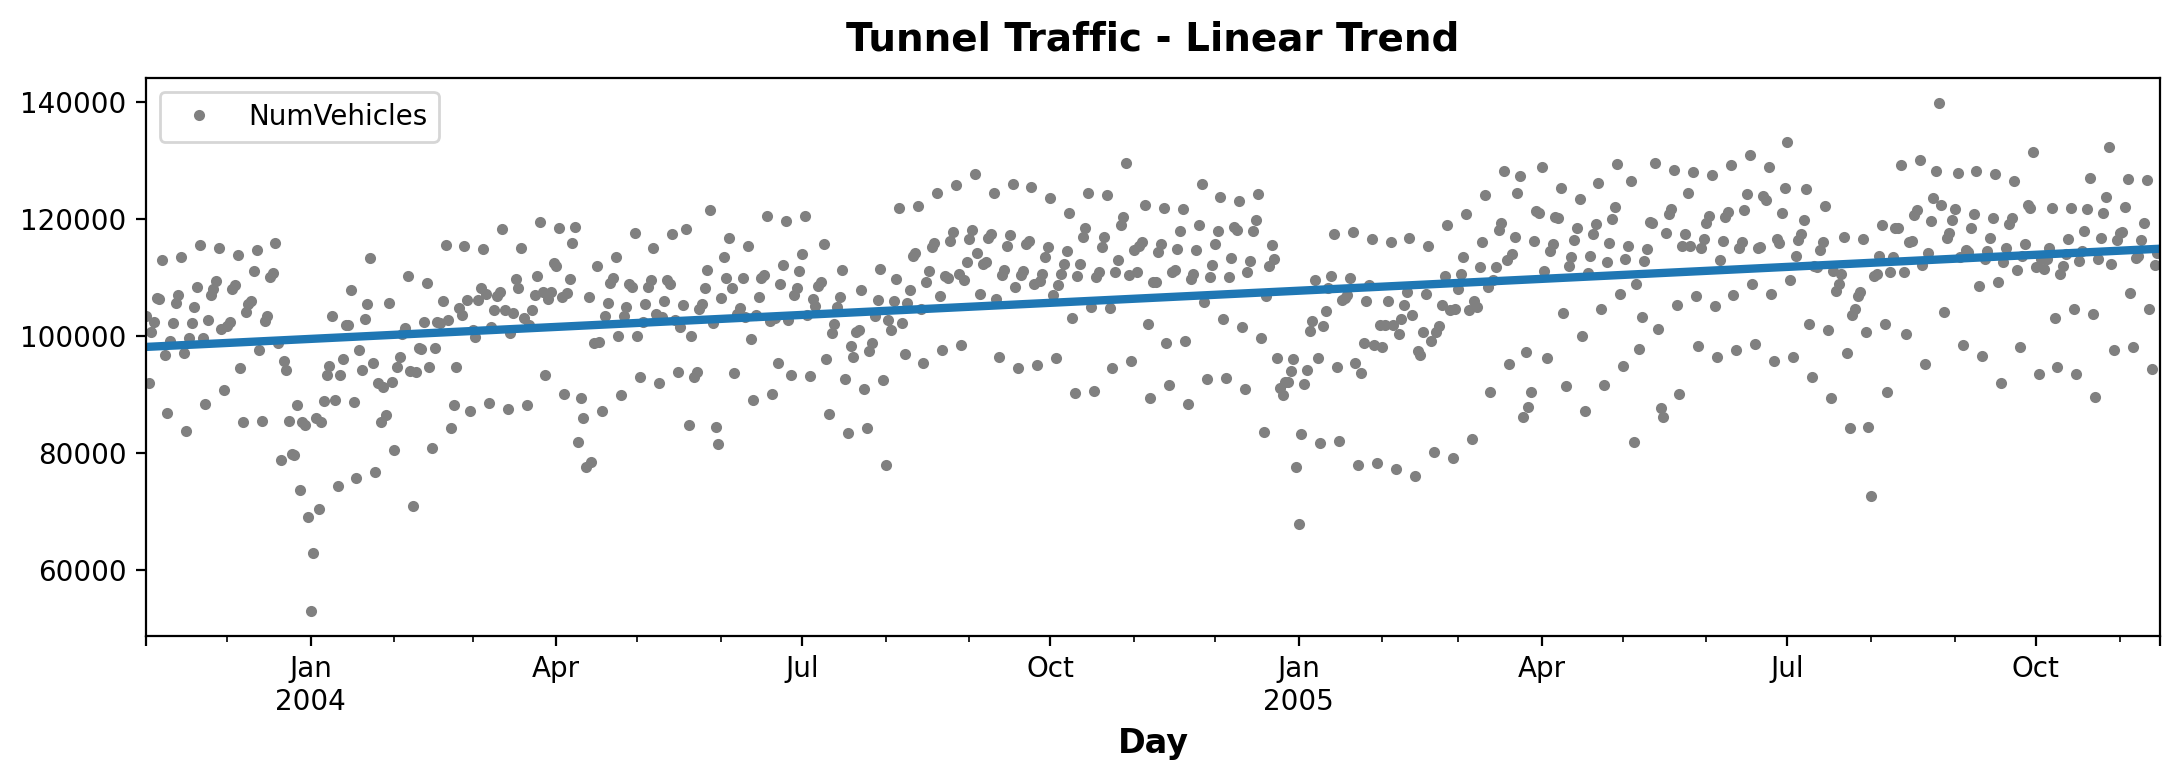

In [ ]:
ax = tunnel.plot(style=".", color="0.5", title="Tunnel Traffic - Linear Trend")
_ = y_pred.plot(ax=ax, linewidth=3, label="Trend")


**To make a forecast**, we apply our model to **out of sample** features.


"Out of sample" refers to times outside of the observation period of the training data. Here's how we could make a 30-day forecast:

In [ ]:
X = dp.out_of_sample(steps=30)

y_fore = pd.Series(model.predict(X), index=X.index)

y_fore.head()

,0
2005-11-17,114981.801146
2005-11-18,115004.298595
2005-11-19,115026.796045
2005-11-20,115049.293494
2005-11-21,115071.790944


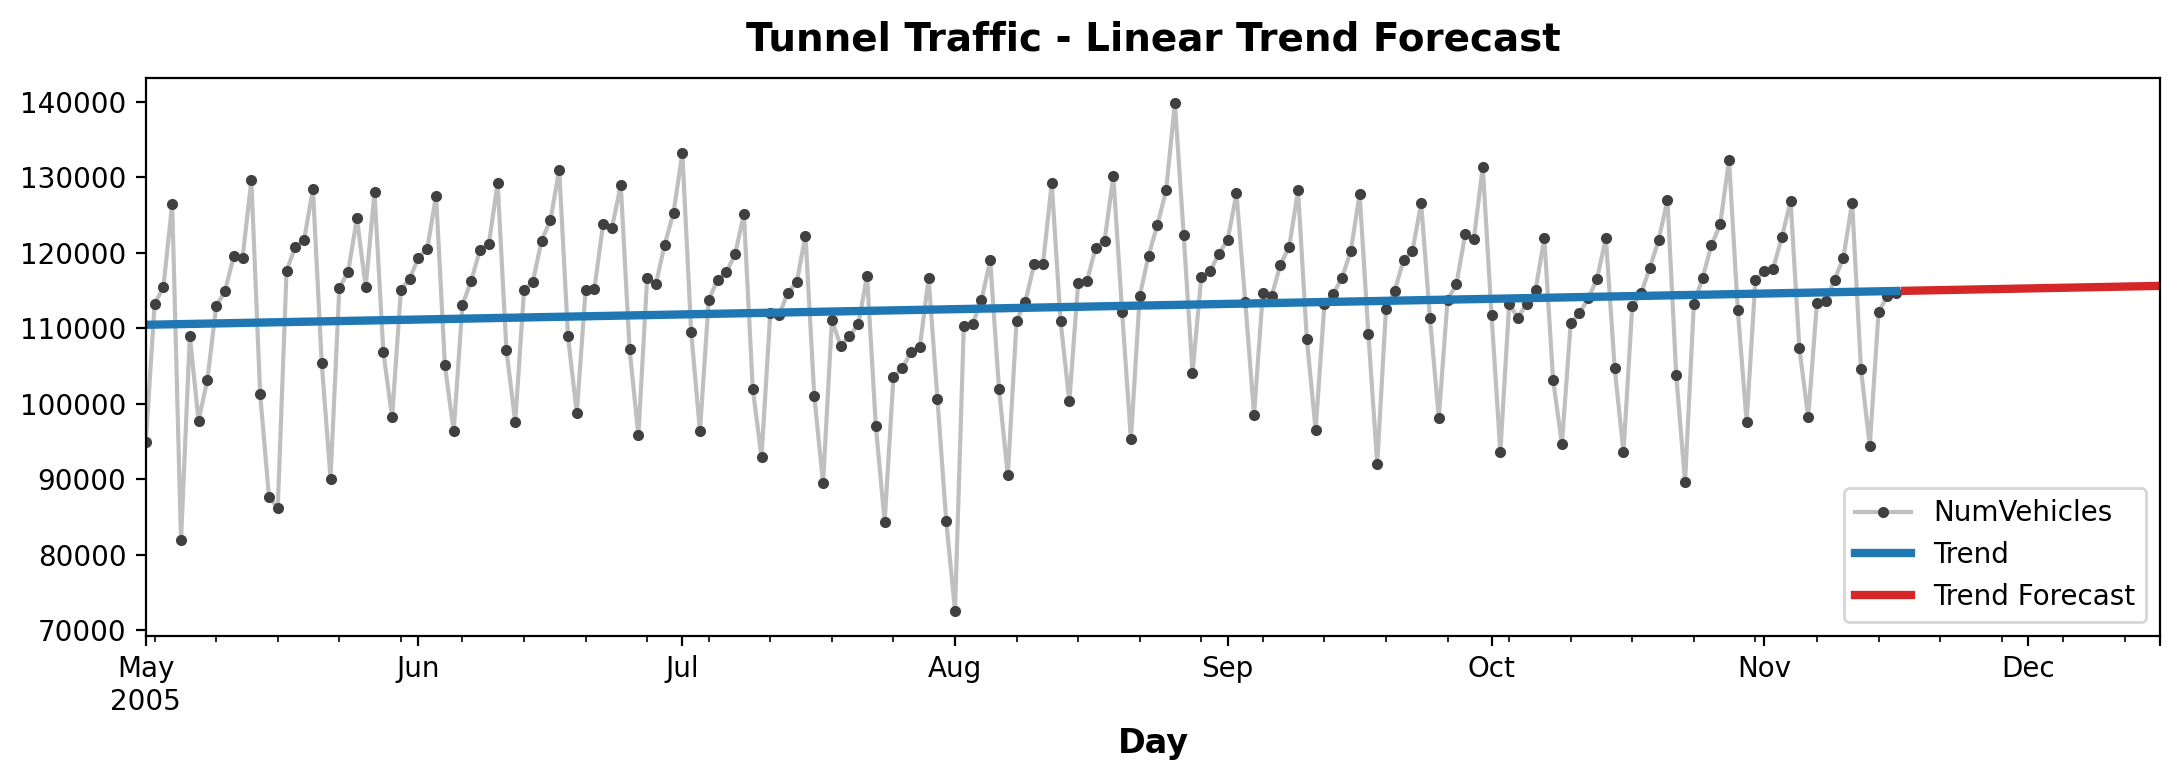

In [ ]:
ax = tunnel["2005-05":].plot(title="Tunnel Traffic - Linear Trend Forecast", **plot_params)
ax = y_pred["2005-05":].plot(ax=ax, linewidth=3, label="Trend")
ax = y_fore.plot(ax=ax, linewidth=3, label="Trend Forecast", color="C3")
_ = ax.legend()

## Seasonality

### Seasonal Indicator

Let's take a look at seasonal plots over a week and over a year.

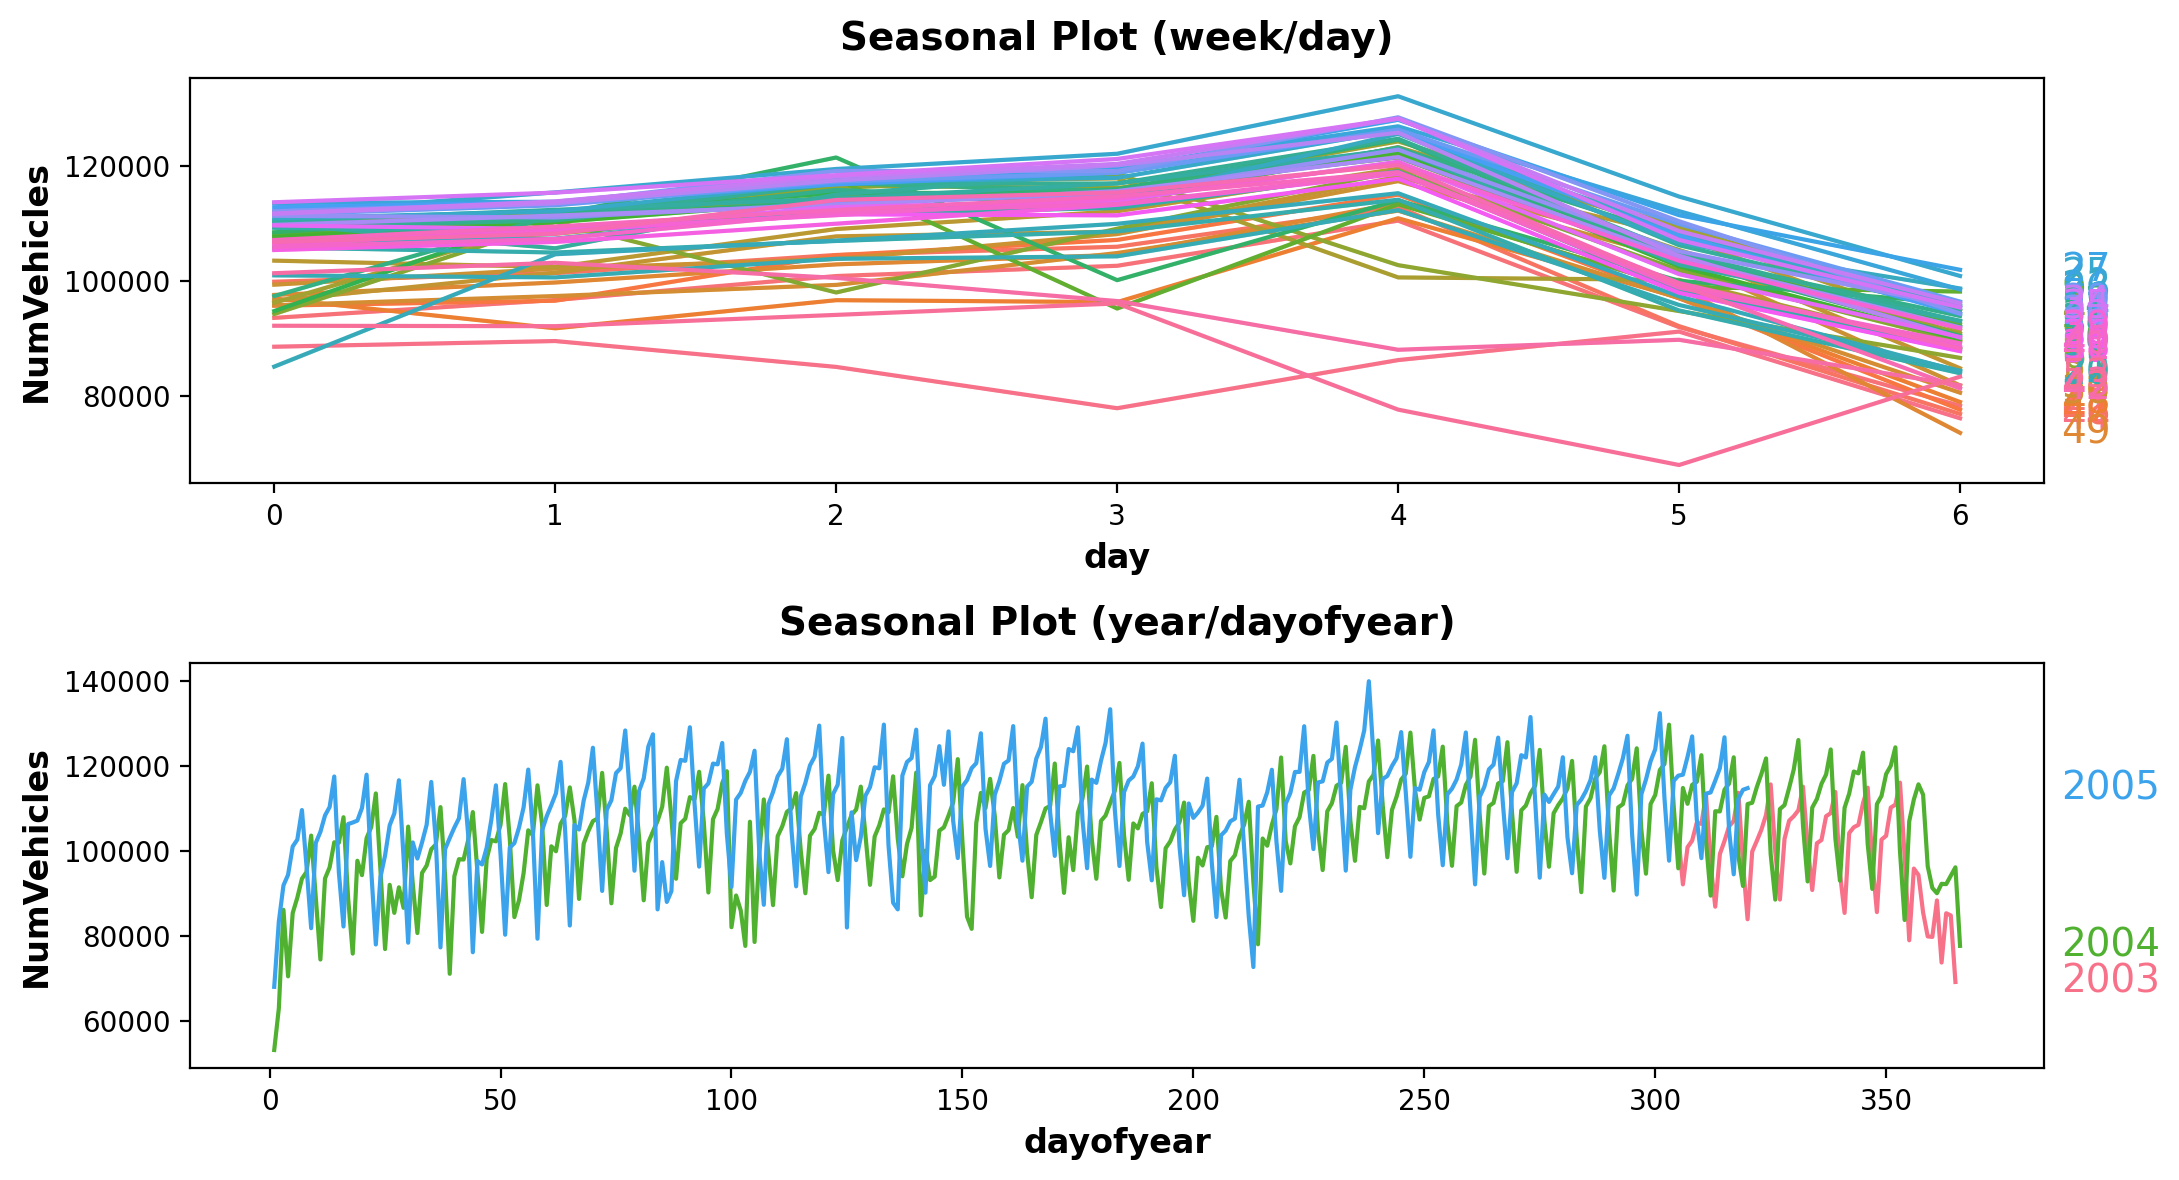

In [ ]:
X = tunnel.copy()

# days within a week
X["day"] = X.index.dayofweek  # the x-axis (freq)
X["week"] = X.index.week  # the seasonal period (period)

# days within a year
X["dayofyear"] = X.index.dayofyear
X["year"] = X.index.year
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 6))
seasonal_plot(X, y="NumVehicles", period="week", freq="day", ax=ax0)
seasonal_plot(X, y="NumVehicles", period="year", freq="dayofyear", ax=ax1);

### Fourier Features for Seasonal Patterns

We'll create our seasonal features using `DeterministicProcess`, the same utility we used to create trend features. To use two seasonal periods (weekly and annual), we'll need to instantiate one of them as an "additional term":

In [ ]:
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

fourier = CalendarFourier(freq="A", order=10)  # 10 sin/cos pairs for "A"nnual seasonality

dp = DeterministicProcess(
    index=tunnel.index,
    constant=True,               # dummy feature for bias (y-intercept)
    order=1,                     # trend (order 1 means linear)
    seasonal=True,               # weekly seasonality (indicators)
    additional_terms=[fourier],  # annual seasonality (fourier)
    drop=True,                   # drop terms to avoid collinearity
)

X = dp.in_sample()  # create features for dates in tunnel.index

With our feature set created, we're ready to fit the model and make predictions. We'll add a 90-day forecast to see how our model extrapolates beyond the training data. The code here is the same as that in earlier lessons.

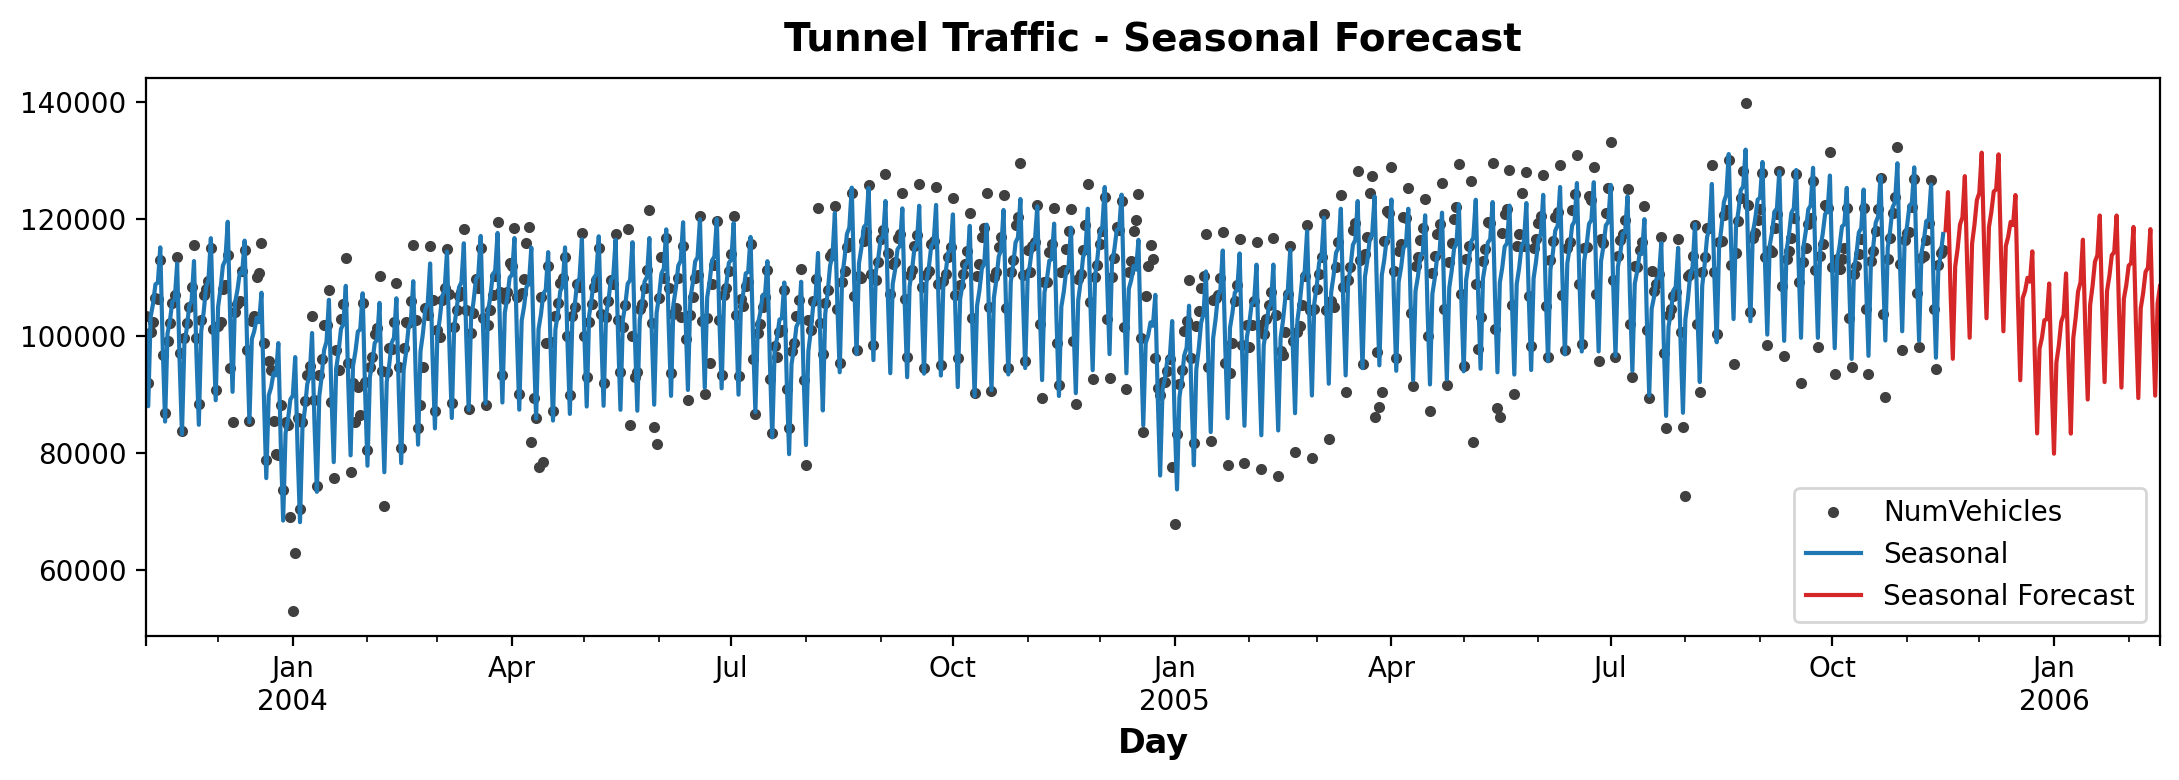

In [ ]:
y = tunnel["NumVehicles"]

model = LinearRegression(fit_intercept=False)
_ = model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=y.index)
X_fore = dp.out_of_sample(steps=90)
y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)

ax = y.plot(color='0.25', style='.', title="Tunnel Traffic - Seasonal Forecast")
ax = y_pred.plot(ax=ax, label="Seasonal")
ax = y_fore.plot(ax=ax, label="Seasonal Forecast", color='C3')
_ = ax.legend()

##  Exponential smoothing practicals
The dataset we are using is electricity consumption time series data.

### Step 1: Load the data

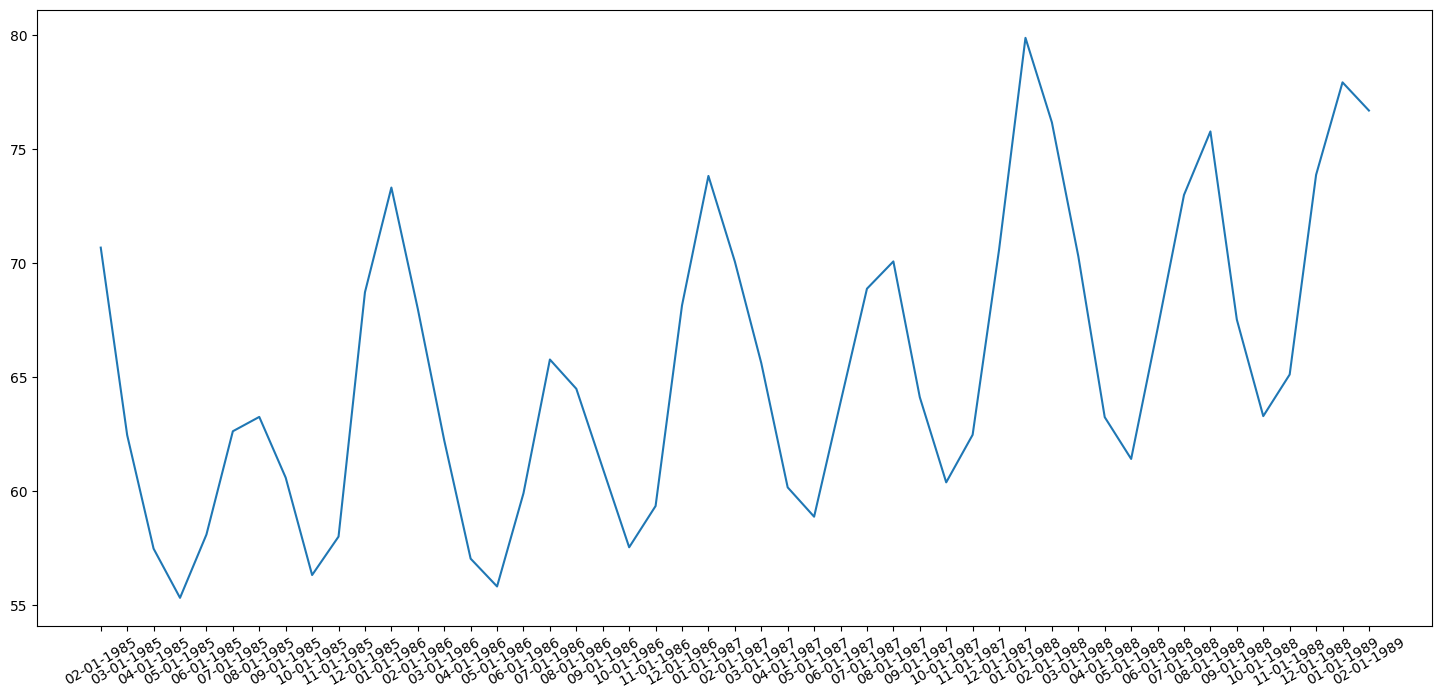

In [ ]:
#import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt
#from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

df = pd.read_csv("https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/refs/heads/main/Dataset/Lecture_Dataset/Electric_Production.csv", header=0, index_col=0)
plt.figure(figsize=(18, 8))
plt.plot(df[1:50]["Value"])
plt.xticks(rotation=30)
#plt.figure()
plt.show()

### Step 2: Moving Average method
We have seen how to calculate the moving average using a window. The same applies to our dataset and we will get rolling statistics and find its mean. After the mean, if we plot the graph then you can see the difference in smoothing of a graph as the original.

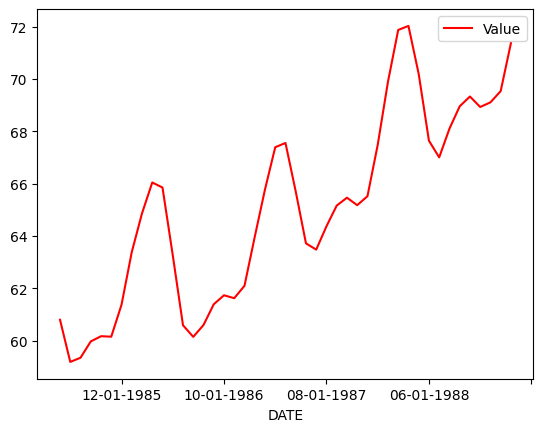

In [ ]:
rollingseries = df[1:50].rolling(window=5)
rollingmean = rollingseries.mean() #we can compute any statistical measure
#print(rollingmean.head(10))
rollingmean.plot(color="red")
plt.show()

### Step 3: Simple Exponential Smoothing
Now as we have seen in simple exponential smoothing has a parameter known as alpha. It defines how much weightage we want to give to recent observations. We will fit 2 models, one with a high value and one with less value of alpha, and compare both.



/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


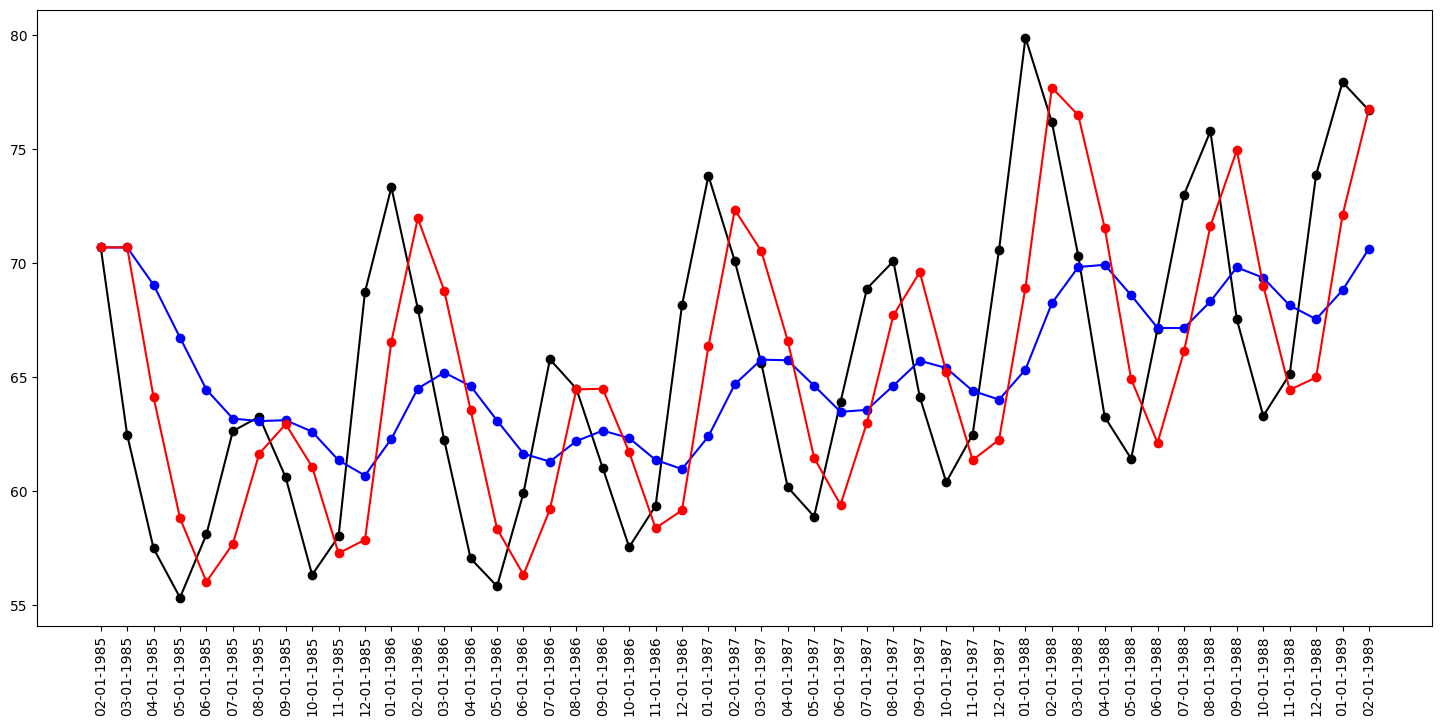

In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
data = df[1:50]
fit1 = SimpleExpSmoothing(data).fit(smoothing_level=0.2, optimized=False)
fit2 = SimpleExpSmoothing(data).fit(smoothing_level=0.8, optimized=False)
plt.figure(figsize=(18, 8))
plt.plot(df[1:50], marker='o', color="black")
plt.plot(fit1.fittedvalues, marker="o", color="b")
plt.plot(fit2.fittedvalues, marker="o", color="r")
plt.xticks(rotation="vertical")
plt.show()

### Step 4: Holt method for exponential smoothing
Hot’s method is a popular method for exponential smoothing and is also known as Linear exponential smoothing. It forecasts the data with the trend. It works on three separate equations that work together to generate the final forecast. Let us apply this to our data and experience the changes. In the first fit, we are assuming that there is a linear trend in data, and in the second fitting, we have exponential smoothing.



/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


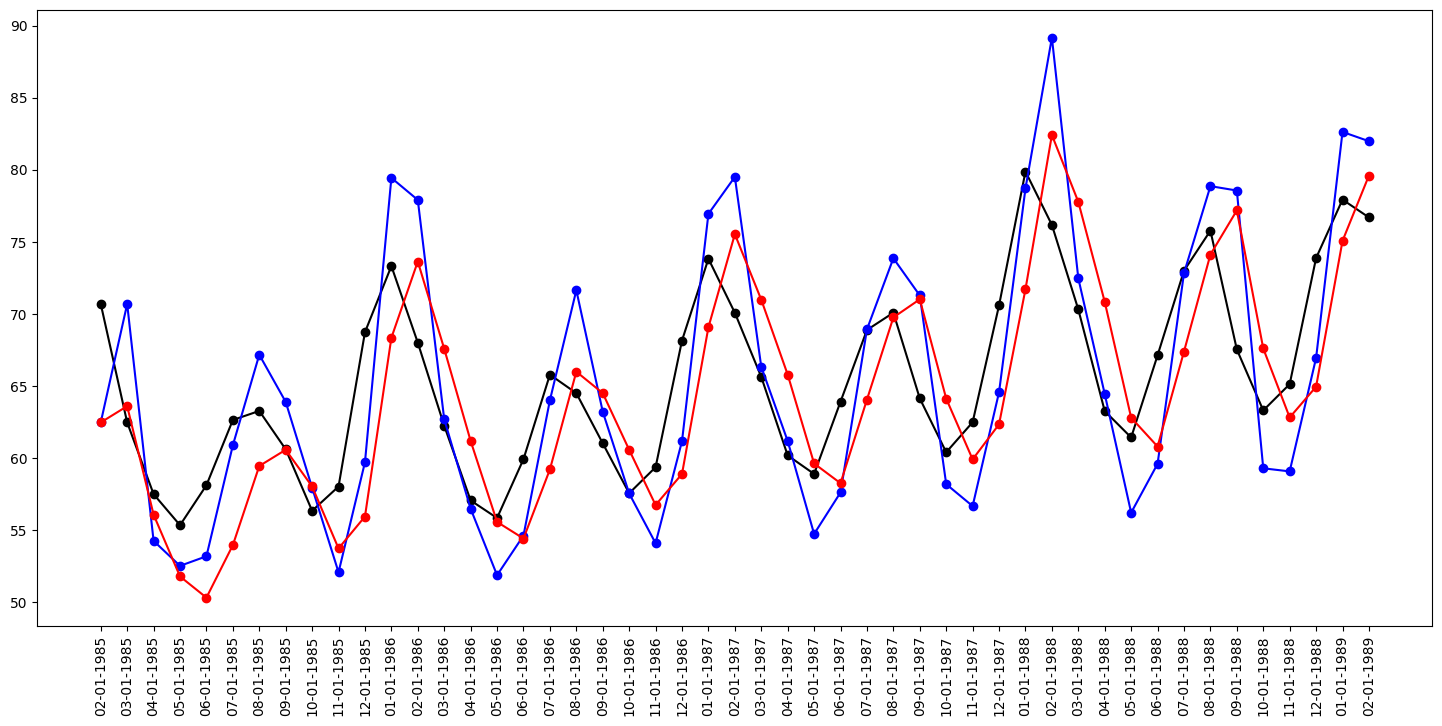

In [ ]:
from statsmodels.tsa.holtwinters import Holt
fit1 = Holt(data).fit()  #linear trend
fit2 = Holt(data, exponential=True).fit()  #exponential trend
plt.figure(figsize=(18, 8))
plt.plot(data, marker='o', color='black')
plt.plot(fit1.fittedvalues, marker='o', color='b')
plt.plot(fit2.fittedvalues, marker='o', color='r')
plt.xticks(rotation="vertical")
plt.show()

You can observe that a linear trend means the blue plot does not fit fine, and follows the original plot whereas the red plot is an exponential smoothing plot. This is a simple smoothing with the Holt method, we also add parameters like alpha, trend component, and seasonality component.

Task

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


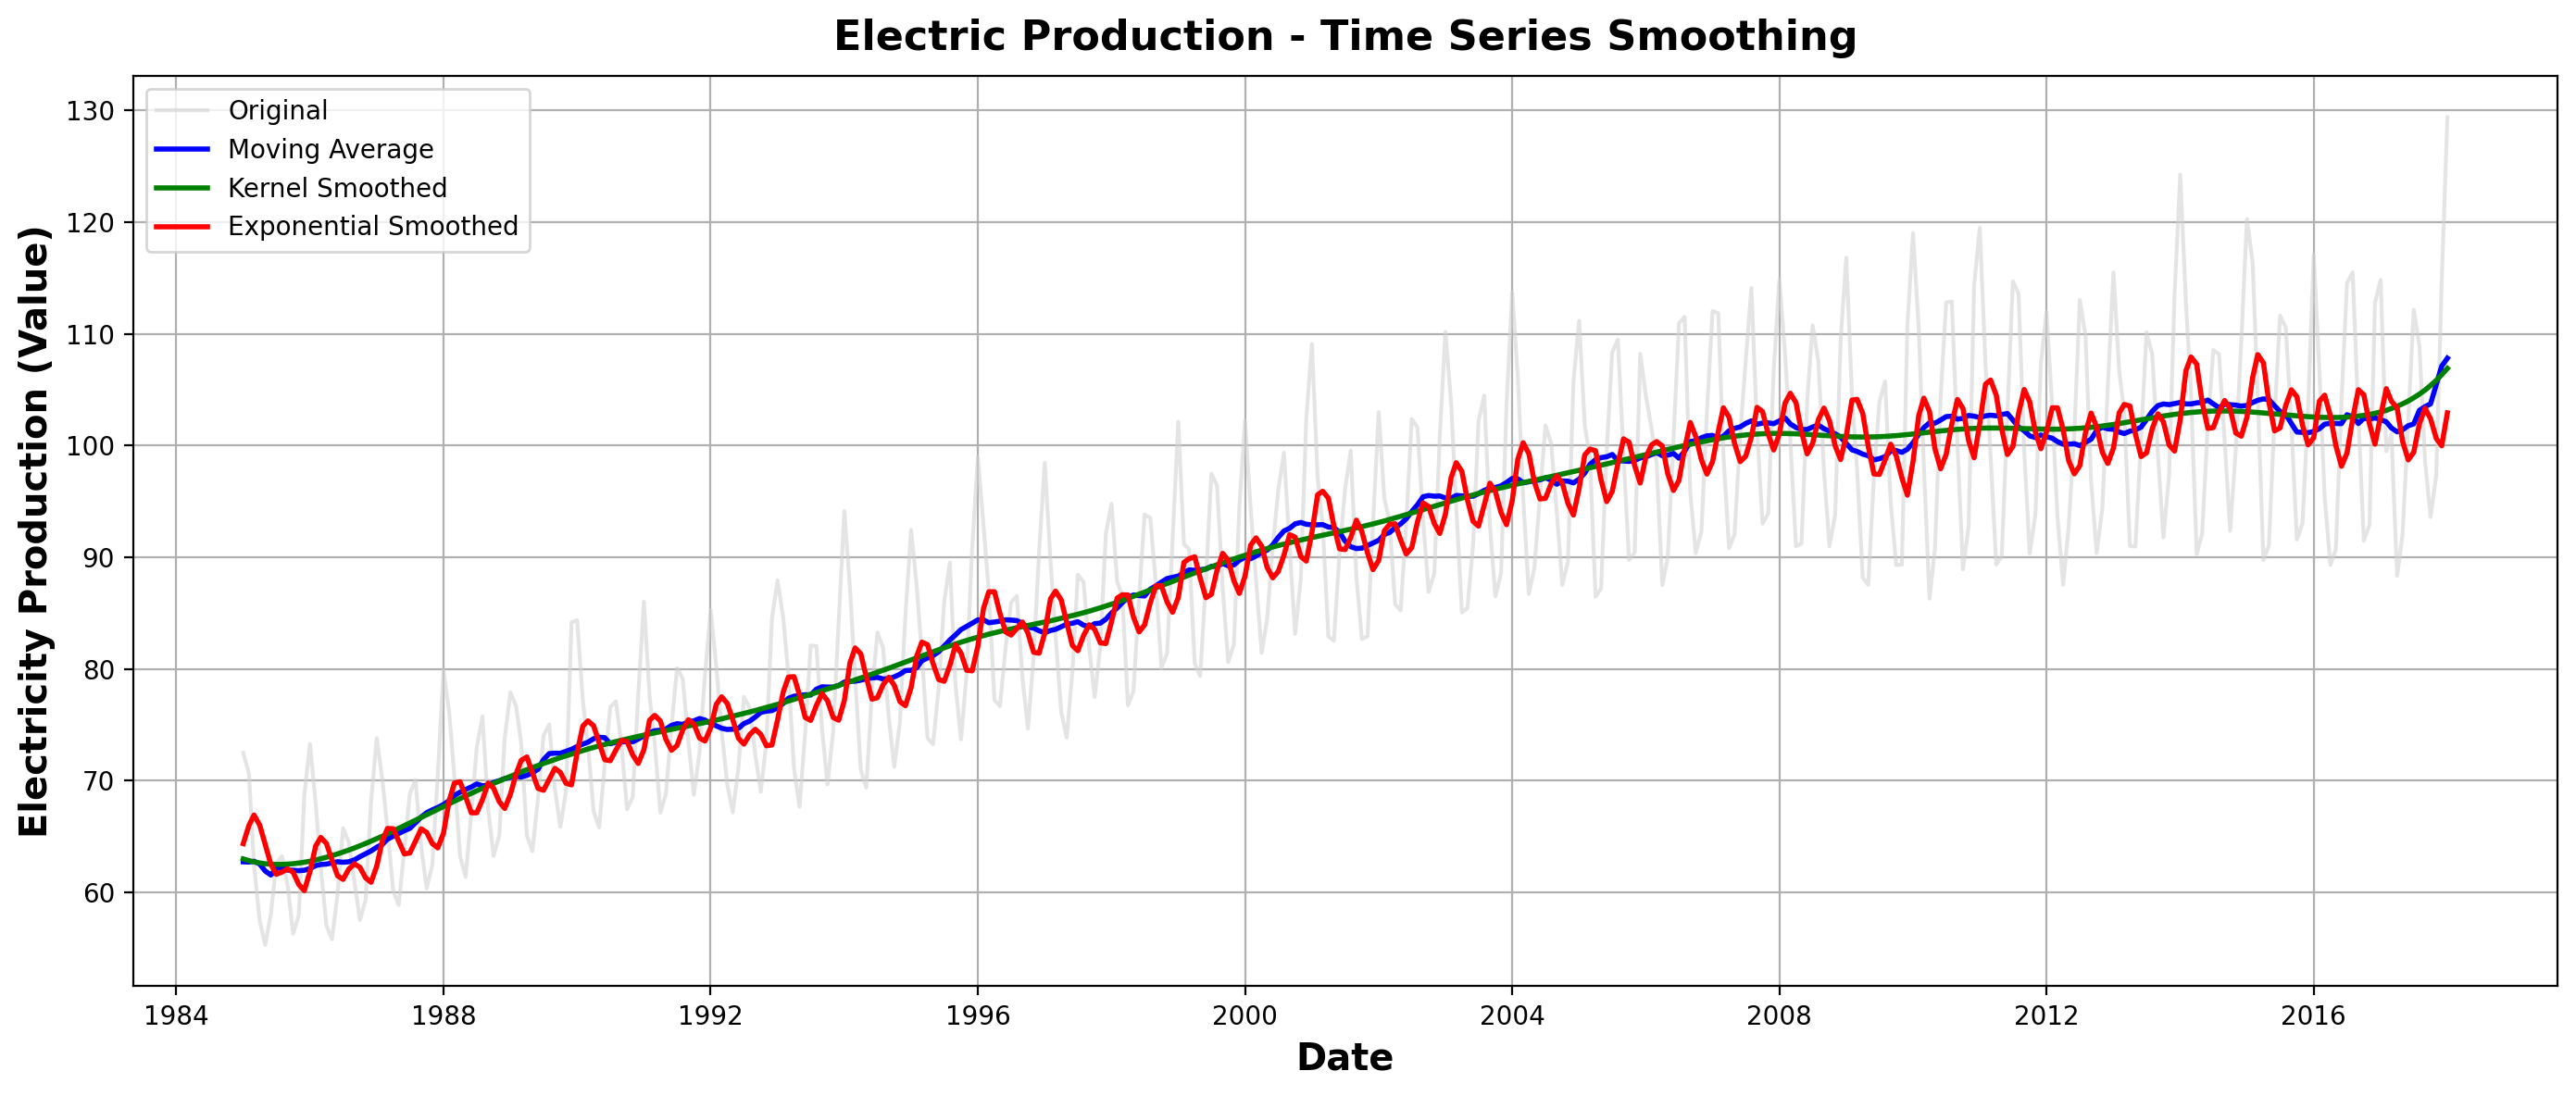

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.kernel_regression import KernelReg
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Load dataset
url = "https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/main/Dataset/Lecture_Dataset/Electric_Production.csv"
df = pd.read_csv(url, parse_dates=["DATE"], index_col="DATE")

# Target column
column_name = "Value"

# --- Moving Average Smoothing ---
moving_avg = df[column_name].rolling(window=12, center=True, min_periods=6).mean()

# --- Kernel Smoothing ---
x = np.arange(len(df))
y = df[column_name].values
kr = KernelReg(endog=y, exog=x, var_type='c', bw=[12])  # Fixed line
y_kernel_smoothed, _ = kr.fit(x)

# --- Exponential Smoothing ---
exp_model = SimpleExpSmoothing(df[column_name], initialization_method="estimated")
exp_fit = exp_model.fit(smoothing_level=0.2)
exp_smoothed = exp_fit.fittedvalues

# --- Plotting All ---
plt.figure(figsize=(14, 6))
plt.plot(df.index, df[column_name], color="lightgray", label="Original", alpha=0.6)
plt.plot(df.index, moving_avg, color="blue", linewidth=2, label="Moving Average")
plt.plot(df.index, y_kernel_smoothed, color="green", linewidth=2, label="Kernel Smoothed")
plt.plot(df.index, exp_smoothed, color="red", linewidth=2, label="Exponential Smoothed")

plt.title("Electric Production - Time Series Smoothing")
plt.xlabel("Date")
plt.ylabel("Electricity Production (Value)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




In [26]:
print(df.columns)


Index(['Value'], dtype='object')
